# Generalised Gain & Response-Time Framework for Alarm Control Actions

A **config-driven engine** that, for any target alarm tag and a set of operator handles, estimates:

- the **direction + gain** of each handle on the target,
- whether the target is **integrating** (ramps, e.g. a level) or **self-regulating** (settles, e.g. a pressure/flow) — auto-classified from data,
- the **response time / action timing** (dead time, settle time, when to take the next action),
- an honest **confidence** (with `directional` for real-but-weak levers and `undetermined` where the data cannot identify a gain).

Demonstrated on `03LIC_1071.PV` (an integrating level); the **same engine** is validated against the vendor APC gain matrix on the pressure/flow pairs that are in the matrix. Environment: `adnoc`.

**Core ideas** (worked out in `docs/gain_analysis_1071_confluence_page.md`):
- estimator = windowed multivariable **difference regression** (de-confounded); **horizon sweep** classifies the dynamics from the shape of gain-vs-horizon;
- **mode-aware**: the target's own closed-loop valve is read on **open-loop (MANUAL)** data (reverse causation), and excluded from the de-confounders for the other handles;
- integrating targets are modelled on the **rate** `d(PV)/dt`; self-regulating targets on the **level change**.

## 1 - Configuration & data foundation
Strict 30-second grid, trip/shutdown windows blanked to NaN, `.OP` handles discovered automatically. Point the framework at a different alarm by editing `CONFIG['TARGET']` and the data paths.

In [1]:
import numpy as np, pandas as pd, os, re, warnings
warnings.filterwarnings('ignore')

DATA = '/home/h604827/ControlActions/DATA'
CONFIG = dict(
    TARGET   = '03LIC_1071.PV',                                                    # alarm tag (the CV)
    PARQUET  = f'{DATA}/PV-OP_data/consolidated_30sec_data/all_tags_30sec.parquet',# PV/OP time series
    EVENTS   = f'{DATA}/combined_events/03LIC_1071_PVLO_PVHI_combined_events.parquet', # operator actions/MODE
    TRIPS    = f'{DATA}/Final_List_Trip_Duration.csv',                             # shutdown windows
    DT_MIN   = 0.5,                                                                # sample period (min)
    HS       = [5, 10, 20, 30, 45, 60, 90, 120, 180],                             # horizon-sweep grid (min)
    RECON    = [('03HIC_1141', 'OP'), ('03HIC_1151', 'OP'), ('03LIC_1034', 'SP')],# handles absent from parquet -> rebuild from events
    WITHIN_BAND_CSV = f'{DATA}/within_limits_periods.csv',                         # 5-95%ile steady operating band (customer-supplied)
    REGIME   = 'within_band',                                                      # 'within_band' (steady 5-95%ile band) or 'all' (full record)
)
DT_MIN = CONFIG['DT_MIN']; TARGET = CONFIG['TARGET']; HS = CONFIG['HS']

# ---- load + strict 30-sec grid + trip filter ----
raw = pd.read_parquet(CONFIG['PARQUET'])
raw['TimeStamp'] = pd.to_datetime(raw['TimeStamp'])
raw = raw.dropna(subset=['TimeStamp']).drop_duplicates('TimeStamp').set_index('TimeStamp').sort_index()
ts = raw.asfreq('30s')
trips = pd.read_csv(CONFIG['TRIPS'])
trips['Stop Date'] = pd.to_datetime(trips['Stop Date'], errors='coerce')
trips['Start Date'] = pd.to_datetime(trips['Start Date'], errors='coerce')
twin = trips.rename(columns={'Stop Date': 'beg', 'Start Date': 'end'})[['beg', 'end']].dropna()
twin = twin[twin['end'] > twin['beg']]
idx = ts.index.values; mask_trip = np.zeros(len(ts), bool)
for b, e in twin.itertuples(index=False):
    mask_trip |= (idx >= np.datetime64(b)) & (idx <= np.datetime64(e))
ts.loc[mask_trip, :] = np.nan
op_tags = sorted(c for c in ts.columns if c.endswith('.OP'))
print(f'grid {ts.shape[0]:,} x {ts.shape[1]} | {ts.index.min()} -> {ts.index.max()}')
print(f'target usable {ts[TARGET].notna().mean()*100:.1f}% | .OP handles {len(op_tags)}')

grid 4,670,040 x 44 | 2021-01-18 12:30:00 -> 2025-06-28 01:29:30
target usable 73.8% | .OP handles 16


## 2 - Operator events: MODE spans (open-loop guard) & reconstructed handles
`MODE` changes give the **MANUAL (open-loop)** spans used to read the target's own valve without controller reverse causation. Handles that are not in the parquet (e.g. `03HIC_1141`) are rebuilt from their `CHANGE` events. The **self handle** (the target's own valve, same instrument number) is identified automatically.

In [6]:
ev = pd.read_parquet(CONFIG['EVENTS'], columns=['VT_Start', 'Source', 'ConditionName', 'Description', 'PrevValue', 'Value'])
ev['VT_Start'] = pd.to_datetime(ev['VT_Start'], errors='coerce')
chg = ev[(ev['ConditionName'] == 'CHANGE') & ev['VT_Start'].notna()].copy()
chg['Vnum'] = pd.to_numeric(chg['Value'], errors='coerce')

def canon_instr(tag):
    # (area, first-letter, number): a controller and its indicator/valve share this key
    t = str(tag).upper().replace('_', '').replace('.', '')
    m = re.match(r'^(\d{1,2})([A-Z]+?)(\d+[A-Z]?\d*)(OP|PV|SP)?$', t)
    return (m.group(1), m.group(2)[0], m.group(3)) if m else None

def manual_spans(tag):
    src = tag.split('.')[0]  # events use the base tag name (no .PV/.OP suffix)
    md = chg[(chg.Source == src) & (chg.Description == 'MODE')][['VT_Start', 'Value']].dropna().sort_values('VT_Start')
    spans, cur = [], None
    for t, v in md.itertuples(index=False):
        man = str(v).upper().startswith('MAN')
        if man and cur is None:
            cur = t
        elif not man and cur is not None:
            spans.append((cur, t)); cur = None
    if cur is not None:
        spans.append((cur, ts.index.max()))
    return spans

def recon(tag, desc):
    # rebuild a handle trajectory on the grid by forward-filling its CHANGE values
    s = chg[(chg.Source == tag) & (chg.Description == desc)].dropna(subset=['Vnum']).copy()
    s['t'] = s['VT_Start'].dt.floor('30s')
    s = s.sort_values('t').drop_duplicates('t', keep='last').set_index('t')['Vnum']
    return s.reindex(ts.index, method='ffill')

for tag, desc in CONFIG['RECON']:
    col = f'{tag}.{desc}__ev'
    if f'{tag}.{desc}' not in ts.columns:
        ts[col] = recon(tag, desc)
        print(f'reconstructed {col}: {ts[col].notna().mean()*100:.0f}% coverage')

TGT_INSTR = canon_instr(TARGET)
SELF_OP = next((t for t in op_tags if canon_instr(t) == TGT_INSTR), None)
print(f'target instrument {TGT_INSTR} | self handle {SELF_OP}')

reconstructed 03HIC_1141.OP__ev: 82% coverage
reconstructed 03HIC_1151.OP__ev: 82% coverage
reconstructed 03LIC_1034.SP__ev: 84% coverage
target instrument ('03', 'L', '1071') | self handle 03LIC_1071.OP


## 3 - Core estimator: difference regression + bootstrap CI
`Delta_H CV = sum_i g_i * Delta_H MV_i + c`, fit jointly over pooled, overlapping windows (de-confounding). `gain_ci` adds a moving-block bootstrap 90% CI (robust to autocorrelation/heteroscedasticity). `solo_r2` is the per-handle single-input explanatory power. For integrating targets we also build the smoothed **rate** `d(PV)/dt`.

In [8]:
def rate_of(col):
    # smoothed centred derivative -> level %/min (the stable quantity for an integrating target)
    s = ts[col].rolling(5, center=True, min_periods=4).mean()
    r = (s.shift(-1) - s.shift(1)) / (2 * DT_MIN)
    r[mask_trip] = np.nan
    return r
ts['_RATE'] = rate_of(TARGET)

def diff_frame(cv, inputs, H_min, seg=None, thin=20, trim=0.001):
    H = max(1, int(round(H_min / DT_MIN)))
    D = pd.DataFrame({c: ts[c].shift(-H) - ts[c] for c in [cv] + inputs})
    if seg is not None:                                   # keep windows whose BOTH ends are in one segment
        D = D[(seg.shift(-H) == seg) & seg.notna()]
    D = D.iloc[::thin].dropna()
    if len(D) and trim:
        lo, hi = D[cv].quantile(trim), D[cv].quantile(1 - trim)
        D = D[(D[cv] >= lo) & (D[cv] <= hi)]
    return D

def _prune(D, cv, inputs, mv):
    return [c for c in inputs if c == mv or (c in D.columns and D[c].std() > 0)]

def diff_gain(cv, inputs, mv, H_min=60, seg=None, thin=20):
    D = diff_frame(cv, inputs, H_min, seg, thin); inputs = _prune(D, cv, inputs, mv)
    if len(D) < 50 or mv not in inputs or D[mv].std() == 0:
        return np.nan, np.nan, len(D)
    y = D[cv].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in inputs] + [np.ones(len(D))])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1 - np.var(y - X @ coef) / np.var(y) if np.var(y) > 0 else np.nan
    return float(coef[inputs.index(mv)]), float(r2), len(D)

def gain_ci(cv, inputs, mv, H_min=60, seg=None, thin=20, nboot=150, block=50, seed=0):
    D = diff_frame(cv, inputs, H_min, seg, thin); n = len(D); inputs = _prune(D, cv, inputs, mv)
    if n < 50 or mv not in inputs or D[mv].std() == 0:
        return dict(g=np.nan, lo=np.nan, hi=np.nan, r2=np.nan, n=n)
    y = D[cv].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in inputs] + [np.ones(n)])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None); j = inputs.index(mv)
    r2 = 1 - np.var(y - X @ coef) / np.var(y) if np.var(y) > 0 else np.nan
    rng = np.random.default_rng(seed); starts = np.arange(max(1, n - block + 1))
    nb = int(np.ceil(n / block)); offs = np.arange(block); bs = np.empty(nboot)
    for k in range(nboot):
        rr = (rng.choice(starts, size=nb)[:, None] + offs[None, :]).ravel(); rr = rr[rr < n][:n]
        cb, *_ = np.linalg.lstsq(X[rr], y[rr], rcond=None); bs[k] = cb[j]
    lo, hi = np.nanpercentile(bs, [5, 95])
    return dict(g=float(coef[j]), lo=float(lo), hi=float(hi), r2=float(r2), n=n)

def solo_r2(cv, mv, H_min=60, seg=None, thin=20):
    D = diff_frame(cv, [mv], H_min, seg, thin)
    if len(D) < 200 or D[mv].std() == 0:
        return np.nan
    y = D[cv].to_numpy(); x = D[mv].to_numpy(); k, b = np.polyfit(x, y, 1)
    return float(1 - np.var(y - (k * x + b)) / np.var(y))
print('estimator ready')

estimator ready


## 4 - Horizon sweep & dynamics auto-classifier
Sweeping the horizon `H` and reading the **shape** of gain-vs-`H` classifies the pair: a **plateau** => self-regulating (gain = plateau, with time-constant `tau`); a **linear ramp** => integrating; a **rise-then-decay** => the controller is rejecting it (a mode-awareness flag).

In [9]:
def horizon_sweep(cv, inputs, mv, seg=None):
    return np.array([diff_gain(cv, inputs, mv, H, seg)[0] for H in HS])

def fit_first_order(H, g):
    # g(H) = K (1 - exp(-(H-theta)/tau)); K linear, tau/theta on a small grid
    ok = np.isfinite(g); H, g = np.asarray(H)[ok], np.asarray(g)[ok]
    if len(H) < 4:
        return None
    best = None
    for tau in np.arange(2, 241, 2):
        for th in (0, 1, 2, 3, 5, 7.5, 10, 15):
            basis = 1 - np.exp(-np.clip(H - th, 0, None) / tau); den = float(basis @ basis)
            if den <= 1e-9:
                continue
            K = float(basis @ g) / den; sse = float(((g - K * basis) ** 2).sum())
            if best is None or sse < best['sse']:
                best = dict(K=K, tau=float(tau), theta=float(th), sse=sse)
    ss = float(((g - g.mean()) ** 2).sum())
    best['r2'] = (1 - best['sse'] / ss) if ss > 0 else np.nan
    return best

def classify(gs):
    g = np.asarray(gs, float)
    if np.all(~np.isfinite(g)) or np.nanmax(np.abs(g)) == 0:
        return dict(cls='undetermined', ramp=np.nan, K=np.nan, tau=np.nan, theta=np.nan, fit_r2=np.nan, slope=np.nan)
    g30 = g[HS.index(30)]; g120 = g[HS.index(120)]
    ramp = g120 / g30 if (np.isfinite(g30) and g30 != 0) else np.nan
    peak = int(np.nanargmax(np.abs(g)))
    decayed = (np.abs(g[-1]) < 0.6 * np.abs(g[peak])) and (peak < len(g) - 2)
    fo = fit_first_order(HS, g)
    slope = np.polyfit(HS, g, 1)[0] if np.all(np.isfinite(g)) else np.nan
    if decayed and not (np.isfinite(ramp) and ramp > 1.5):
        cls = 'rejection'
    elif np.isfinite(ramp) and ramp >= 2.5:
        cls = 'integrating'
    elif fo is not None and fo['r2'] >= 0.5 and np.isfinite(ramp) and abs(ramp - 1) < 0.8:
        cls = 'self_regulating'
    elif np.isfinite(ramp) and abs(ramp - 1) < 0.6:
        cls = 'self_regulating'
    else:
        cls = 'undetermined'
    return dict(cls=cls, ramp=ramp, K=(fo['K'] if fo else np.nan), tau=(fo['tau'] if fo else np.nan),
                theta=(fo['theta'] if fo else np.nan), fit_r2=(fo['r2'] if fo else np.nan), slope=slope)
print('sweep + classifier ready')

sweep + classifier ready


## 5 - Response time, action timing, target class & confidence
- **Dead time** (onset) = lag where a handle's change best correlates with the target rate.
- **Action timing**: `wait` (dead time), `settle` (`theta + 3*tau`, self-regulating), `next_action` (re-evaluate).
- **Target class**: physics prior by instrument letter (`L`=level=integrating, `F`=flow=self-regulating), pressure/temperature data-tested via the self-valve sweep.
- **Confidence**: sign **first** (does the bootstrap CI exclude 0?), then R2 for magnitude strength; `directional` = trustworthy sign but weak magnitude.

In [10]:
def onset_xcorr(mv_col, max_lag_min=20):
    d = pd.DataFrame({'h': ts[mv_col].diff(), 'r': ts['_RATE']}).dropna()
    lags = np.arange(0, int(round(max_lag_min / DT_MIN)) + 1)
    cc = np.array([d['h'].corr(d['r'].shift(-L)) for L in lags])
    if np.all(~np.isfinite(cc)):
        return np.nan, np.nan
    k = int(np.nanargmax(np.abs(cc)))
    return lags[k] * DT_MIN, float(cc[k])

def action_timing(theta, tau, cls):
    th = 0.0 if not np.isfinite(theta) else max(theta, 0.0)
    if cls == 'self_regulating' and np.isfinite(tau):
        return dict(wait_min=round(th, 1), effect63_min=round(th + tau, 1),
                    settle_min=round(th + 3 * tau, 1), next_action_min=round(th + 3 * tau, 1))
    if cls == 'integrating':
        return dict(wait_min=round(th, 1), effect63_min=np.nan, settle_min=np.nan, next_action_min=round(th + 5, 1))
    return dict(wait_min=round(th, 1), effect63_min=np.nan, settle_min=np.nan, next_action_min=np.nan)

def rate_solo_r2(mv, mask, thin=4):
    D = pd.DataFrame({'r': ts['_RATE'], 'x': ts[mv]})[mask].iloc[::thin].dropna()
    if len(D) < 200 or D['x'].std() == 0:
        return np.nan, len(D)
    y = D['r'].to_numpy(); x = D['x'].to_numpy(); k, b = np.polyfit(x, y, 1)
    return float(1 - np.var(y - (k * x + b)) / np.var(y)), len(D)

def rate_gain1(mv, mask, deconf, thin=4, nboot=150, block=50, seed=0):
    # integrating gain of ONE handle on the target's RATE, de-confounded against a SMALL core set
    # (a small input set avoids the multi-column dropna collapse from scattered historian NaNs).
    cols = [mv] + [c for c in deconf if c in ts.columns and c != mv]
    D = pd.DataFrame({'r': ts['_RATE']})
    for c in cols:
        D[c] = ts[c]
    D = D[mask].iloc[::thin].dropna(); cols = [c for c in cols if D[c].std() > 0]; n = len(D)
    if n < 200 or mv not in cols:
        return None
    y = D['r'].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in cols] + [np.ones(n)])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None); j = cols.index(mv)
    rng = np.random.default_rng(seed); starts = np.arange(max(1, n - block + 1))
    nb = int(np.ceil(n / block)); offs = np.arange(block); bs = np.empty(nboot)
    for k in range(nboot):
        rr = (rng.choice(starts, size=nb)[:, None] + offs[None, :]).ravel(); rr = rr[rr < n][:n]
        cb, *_ = np.linalg.lstsq(X[rr], y[rr], rcond=None); bs[k] = cb[j]
    lo, hi = np.nanpercentile(bs, [5, 95])
    return dict(g=float(coef[j]), lo=float(lo), hi=float(hi), n=n)

def classify_target(INPUTS):
    letter = TGT_INSTR[1] if TGT_INSTR else '?'
    if letter == 'L':
        return 'integrating'
    if letter == 'F':
        return 'self_regulating'
    if SELF_OP:
        cl = classify(horizon_sweep(TARGET, INPUTS + [SELF_OP], SELF_OP, None))
        return 'integrating' if cl['cls'] == 'integrating' else 'self_regulating'
    return 'self_regulating'

def confidence(g, lo, hi, r2_solo, n):
    # sign FIRST (is the direction identified?), then R2 for magnitude strength.
    if not np.isfinite(g) or n < 200:
        return 'undetermined'
    signed = (lo > 0 and hi > 0) or (lo < 0 and hi < 0)
    if not signed:
        return 'undetermined'
    r2 = r2_solo if np.isfinite(r2_solo) else 0.0
    return 'high' if r2 >= 0.10 else 'medium' if r2 >= 0.03 else 'directional'
print('timing + target-class + confidence ready')

timing + target-class + confidence ready


## 6 - Validate the method against the vendor APC gain matrix (do this first)

`03LIC_1071` is **not** in the vendor matrix (it is a base-layer DCS level, not an APC CV), so before deriving anything for the target we first validate the **estimator itself** on the pressure / flow / temperature pairs that *are* in the matrix. If the same de-confounded difference regression reproduces the vendor gains where a vendor number exists, we can trust it on the target where none does.

The larger 1-min history (`new_rca_pv_op_data/merged_all_historian_tags.parquet`, + the old per-export 1-min files, + the 30-sec consolidated file downsampled to 1-min — the historian 1-min series is exactly the `:00`-second subset of the 30-sec data) makes **26** vendor `(MV -> CV)` cells testable, up from the 2 pressure anchors reachable on 30-sec alone. This block is **self-contained** (its own 1-min frame `tsv`; it does not touch the 30-sec `ts` used for the target below).

### How the vendor gains are actually derived — read each CV **column** jointly (de-confounder choice)

A vendor gain is **not** a stand-alone pairwise number. Each **column** of the matrix (one CV) is a single **multivariable** model: `CV = sum_i K_i * MV_i` over exactly the MVs that have a **non-empty cell** in that column. So a cell `K(MV -> CV)` is a **partial** steady-state gain — the effect of that MV on the CV **holding the other MVs in the same column constant** — and it was identified with all those column-mates moving together. An empty cell means "assumed no effect", i.e. that MV is simply **not** part of that CV's model.

Concretely this means: to reproduce a cell we must de-confound each MV against **the other MVs that share its CV column** (the ones we have data for), **not** a fixed base set. Earlier this block de-confounded every pair against a fixed trio (feed + `03PIC_1013.OP` + `03TIC_1092.OP`); we now build the de-confounder set **per CV column** straight from the matrix (`COLMATE`, mapped vendor->our names). Because a coefficient in a multiple regression depends on which co-regressors are included, this is the apples-to-apples comparison. The table below reports **both** so the change is visible: `band_gain_base` (old fixed trio) vs `band_gain_col` (column-matched), with `deconf_used` listing the actual column-mates and `n_deconf` their count.

**Honest limit:** we can only de-confound against column-mates we have historian data for. Several vendor column-mates are unavailable (`AMBIENT`, the fin-fan banks `3E1xx_FANS`, and some `03HIC_...` clamps), so for those columns the match is **partial** — direction stays reliable, magnitude can still be attenuated by the missing column-mate. Sign is robust to the de-confounder set; magnitude is what this change most affects.

For each pair we report the vendor gain, our derived gain on the **5-95%ile steady operating band** (the regime that recovers open-loop magnitude), the **sign match** (the reliable claim), a 90% moving-block bootstrap CI, and the single-input R2 (a trust proxy).

- **Categories** — `already_validated_30sec` (1-min consistency check) | `revived_dead_cv` (`03TI_1081`, 100% NaN on 30-sec, now testable) | `new_untested` (first derived numbers) | `within_loop_caution` (MV and CV are the *same* instrument = controller-inverse coupling, **not** a process gain).
- **`mv_proxy`** — `FF=PV` (a feed-forward signal *is* the measured value, so the regressor is the loop `.PV` — correct native mapping, not a substitution) | `SP->PV proxy` (no `.SP` in history; use the loop `.PV` since `PV ~= SP` at steady state — read these as **indicative**, direction over magnitude) | `OP 30sec->1min` (real `.OP`, downsampled).

**Takeaway carried into the target derivation:** direction reproduces on the well-excited exogenous anchors; magnitude recovers toward the open-loop vendor value **in the steady band** for those paths (e.g. `feed -> 1141A`), and stays attenuated for regulated / parked / weakly-excited handles — each for a stated physical reason (closed-loop rejection, operating-point averaging, or a missing column-mate).


In [2]:
# ============================================================================
#  METHOD VALIDATION vs VENDOR APC MATRIX  -- self-contained 1-min pipeline
#  (independent of the 30-sec `ts` used for the 1071 derivation further below)
# ============================================================================
import glob
import pyarrow.parquet as pq

NEW_FILE = f'{DATA}/new_rca_pv_op_data/merged_all_historian_tags.parquet'      # big 1-min merged history
OLD_DIR  = f'{DATA}/PV-OP_data'                                                # 8 per-export 1-min files
SEC30    = f'{DATA}/PV-OP_data/consolidated_30sec_data/all_tags_30sec.parquet' # 30-sec -> downsample to 1-min
GAINCSV  = f'{DATA}/Gain Data 12Mar26(Sheet1).csv'                             # vendor APC gain matrix
DTV      = 1.0                                                                 # vendor-validation cadence (min)

# vendor pairs: (vendor_MV, vendor_CV, our_MV, our_CV, vendor_gain, category, mv_proxy) -- from gain_1min_new_pairs
VPAIRS = [
    ('03PIC1013OP', '03PIC1141APV', '03PIC_1013.OP', '03PI_1141A.PV',  -11.2353, 'already_validated_30sec', ''),
    ('02FI1000FF',  '03PIC1141APV', '02FI_1000.PV',  '03PI_1141A.PV',  +74.3774, 'already_validated_30sec', 'FF=PV'),
    ('02FI1000FF',  '03TIC1145PV',  '02FI_1000.PV',  '03TIC_1145.PV',   +0.6790, 'already_validated_30sec', 'FF=PV'),
    ('03FIC3435OP', '02FI1000PV',   '03FIC_3435.OP', '02FI_1000.PV',    +0.0066, 'already_validated_30sec', 'feed as CV; OP 30sec->1min'),
    ('02FI1000FF',  '03TI1081PV',   '02FI_1000.PV',  '03TI_1081.PV',    +2.0399, 'revived_dead_cv',         'FF=PV'),
    ('03PIC1013OP', '03TI1081PV',   '03PIC_1013.OP', '03TI_1081.PV',    -0.0869, 'revived_dead_cv',         ''),
    ('03TIC1092SP', '03TI1081PV',   '03TIC_1092.PV', '03TI_1081.PV',    -0.4440, 'revived_dead_cv',         'SP->PV proxy'),
    ('02FI1000FF',  '03PI3154.PV',  '02FI_1000.PV',  '03PI_3154.PV',    +0.5043, 'new_untested',            'FF=PV'),
    ('02FI1000FF',  '03TI3112PV',   '02FI_1000.PV',  '03TI_3112.PV',    +0.6446, 'new_untested',            'FF=PV'),
    ('03FIC3435FF', '02PI1220PV',   '03FIC_3435.PV', '02PI_1220.PV',    -0.0400, 'new_untested',            'FF=PV'),
    ('03FIC3435FF', '03TI3112PV',   '03FIC_3435.PV', '03TI_3112.PV',    +0.0609, 'new_untested',            'FF=PV'),
    ('03FIC3435OP', '02PI1220PV',   '03FIC_3435.OP', '02PI_1220.PV',    -0.0766, 'new_untested',            'OP 30sec->1min'),
    ('03FIC3435OP', '03KM0152IPV',  '03FIC_3435.OP', '03KM_0152_I.PV',  -0.2466, 'new_untested',            'OP 30sec->1min'),
    ('03TIC1092SP', '03LIC3408PV',  '03TIC_1092.PV', '03LIC_3408.PV',   +8.2690, 'new_untested',            'SP->PV proxy'),
    ('02FI1000FF',  '03HIC1023AOP', '02FI_1000.PV',  '03HIC_1023A.OP',  +9.4064, 'new_untested',            'FF=PV'),
    ('02FI1000FF',  '03LIC3153OP',  '02FI_1000.PV',  '03LIC_3153.OP',   +3.3721, 'new_untested',            'FF=PV'),
    ('02FI1000FF',  '03PIC1023OP',  '02FI_1000.PV',  '03PIC_1023.OP',   +6.9361, 'new_untested',            'FF=PV'),
    ('02FI1000FF',  '03TI1005PV',   '02FI_1000.PV',  '03TI_1005.PV',    +0.2361, 'new_untested',            'FF=PV'),
    ('03PIC1013OP', '03HIC1023AOP', '03PIC_1013.OP', '03HIC_1023A.OP',  -1.0989, 'new_untested',            ''),
    ('03TIC1009SP', '03HIC1023AOP', '03TIC_1009.PV', '03HIC_1023A.OP',  -2.7995, 'new_untested',            'SP->PV proxy'),
    ('03TIC1009SP', '03TI1108PV',   '03TIC_1009.PV', '03TI_1108.PV',    +0.9910, 'new_untested',            'SP->PV proxy'),
    ('03TIC1023SP', '03PIC1023OP',  '03TIC_1023.PV', '03PIC_1023.OP',   -1.9645, 'new_untested',            'SP->PV proxy'),
    ('03TIC1092SP', '03TI1108PV',   '03TIC_1092.PV', '03TI_1108.PV',    +0.5496, 'new_untested',            'SP->PV proxy'),
    ('03TIC1092SP', '03TIC1009OP',  '03TIC_1092.PV', '03TIC_1009.OP',   -3.4350, 'new_untested',            'SP->PV proxy'),
    ('03TIC1009SP', '03TIC1009OP',  '03TIC_1009.PV', '03TIC_1009.OP',   +1.5922, 'within_loop_caution',     'SP->PV proxy, self-loop'),
    ('03TIC1092SP', '03TIC1092OP',  '03TIC_1092.PV', '03TIC_1092.OP',  -34.6996, 'within_loop_caution',     'SP->PV proxy, self-loop'),
]
VBASE = ['02FI_1000.PV', '03PIC_1013.OP', '03TIC_1092.OP']   # OLD fixed base de-confounders (feed + 2 clean handles) - kept only for the before/after comparison

def _canon_instr_v(col):
    t = str(col).upper().replace('_', '').replace('.', '').replace(' ', '')
    m = re.match(r'^(\d{1,2})([A-Z]+?)(\d+[A-Z]?\d*)(OP|PV|SP|DV|FF)?$', t)
    return (m.group(1), m.group(2)[0], m.group(3)) if m else col

# ---- vendor gain MATRIX: each CV column is a JOINT model over its non-empty MVs -----------------
# K(MV->CV) is a PARTIAL steady-state gain (effect of that MV holding the OTHER column-MVs constant),
# so to reproduce a cell we de-confound each MV against the other MVs that share its CV column
# (COLMATE), NOT a fixed base. An empty cell => that MV is not part of the CV's model.
gm = pd.read_csv(GAINCSV, index_col=0)                       # rows = vendor MVs, cols = vendor CVs
V2O = {}                                                     # vendor tag name -> our data column (trusted map)
for _vmv, _vcv, _omv, _ocv, *_ in VPAIRS:
    V2O[_vmv] = _omv; V2O[_vcv] = _ocv

def vendor_to_our(vname):
    # VPAIRS supplies the fuzzy / SME-confirmed mappings; the regex handles the mechanical ones
    # (OP -> .OP; FF/SP/PV/DV -> .PV, since a feed-forward IS the measured PV and we use the loop
    # .PV as an SP proxy). Returns None if it cannot be mapped.
    if vname in V2O:
        return V2O[vname]
    t = str(vname).upper().replace(' ', '').replace('_', '').replace('.', '')
    m = re.match(r'^(\d{1,2})([A-Z]+?)(\d+[A-Z]?\d*)(OP|SP|FF|PV|DV)$', t)
    if not m:
        return None
    a, l, n, s = m.groups()
    return f'{a}{l}_{n}.OP' if s == 'OP' else f'{a}{l}_{n}.PV'

COLMATE = {}                                                 # vendor_CV -> [our-name column-mate MVs]
for _vcv in {p[1] for p in VPAIRS}:
    if _vcv in gm.columns:
        _ours = [vendor_to_our(mv) for mv in gm.index[gm[_vcv].notna()]]
        COLMATE[_vcv] = list(dict.fromkeys([o for o in _ours if o]))
    else:
        COLMATE[_vcv] = []

needv = set(VBASE)
for _p in VPAIRS:
    needv.add(_p[2]); needv.add(_p[3])          # our_MV, our_CV of every pair
for _mates in COLMATE.values():
    needv.update(_mates)                        # + column-mates so the loader fetches every de-confounder
needv = sorted(needv)
_pair_cols = {p[2] for p in VPAIRS} | {p[3] for p in VPAIRS}   # tags that MUST resolve (warn only for these)

# ---- 3-tier resolution: new 1-min merged -> old 1-min per-export -> 30-sec downsampled to 1-min -------
def _schema(fp):
    return set(pq.ParquetFile(fp).schema_arrow.names)

_new_cols = _schema(NEW_FILE); _old_files = sorted(glob.glob(f'{OLD_DIR}/*.parquet'))
_old_schema = {fp: _schema(fp) for fp in _old_files}; _sec_cols = _schema(SEC30)
provenance_v, frames_v = {}, []

_from_new = [c for c in needv if c in _new_cols]
_dn = pd.read_parquet(NEW_FILE, columns=['TimeStamp'] + _from_new)
_dn['TimeStamp'] = pd.to_datetime(_dn['TimeStamp'], errors='coerce')
_dn = _dn.dropna(subset=['TimeStamp']).drop_duplicates('TimeStamp').set_index('TimeStamp').sort_index()
frames_v.append(_dn); provenance_v.update({c: 'new_merged_1min' for c in _from_new})

_by_src, _still = {}, []
for col in [c for c in needv if c not in _new_cols]:
    src = next((fp for fp in _old_files if col in _old_schema[fp]), None)
    if src:
        _by_src.setdefault(src, []).append(col); provenance_v[col] = f'old_1min:{os.path.basename(src)}'
    else:
        _still.append(col)
for src, cols in _by_src.items():
    d = pd.read_parquet(src, columns=['TimeStamp'] + cols)
    d['TimeStamp'] = pd.to_datetime(d['TimeStamp'], errors='coerce')
    d = d.dropna(subset=['TimeStamp']).drop_duplicates('TimeStamp').set_index('TimeStamp').sort_index()
    frames_v.append(d[cols])

tsv = pd.concat(frames_v, axis=1).asfreq('1min')

_from_30 = [c for c in _still if c in _sec_cols]
for col in [c for c in _still if c not in _sec_cols]:
    if col in _pair_cols:                                    # column-mate-only extras are optional -> silent
        print(f'  !! {col} not found in any source -> its pairs will be skipped')
if _from_30:
    d30 = pd.read_parquet(SEC30, columns=['TimeStamp'] + _from_30)
    d30['TimeStamp'] = pd.to_datetime(d30['TimeStamp'], errors='coerce')
    d30 = d30.dropna(subset=['TimeStamp']).drop_duplicates('TimeStamp').set_index('TimeStamp').sort_index()
    for col in _from_30:
        tsv[col] = d30[col].reindex(tsv.index); provenance_v[col] = '30sec->1min'

# ---- trip filter (reuse the Part 1 trip windows `twin`) ----
_idxv = tsv.index.values; _mtv = np.zeros(len(tsv), bool)
for b, e in twin.itertuples(index=False):
    _mtv |= (_idxv >= np.datetime64(b)) & (_idxv <= np.datetime64(e))
tsv.loc[_mtv, :] = np.nan

# ---- 5-95%ile steady band on the 1-min grid (same within_band regime as the target) ----
_wl = pd.read_csv(CONFIG['WITHIN_BAND_CSV'])
_wl['StartTime'] = pd.to_datetime(_wl['StartTime'], errors='coerce')
_wl['EndTime'] = pd.to_datetime(_wl['EndTime'], errors='coerce')
_wl = _wl.dropna(subset=['StartTime', 'EndTime'])
def _spans_to_seg_v(index, starts, ends):
    a = np.asarray(starts, 'datetime64[ns]'); b = np.asarray(ends, 'datetime64[ns]')
    o = np.argsort(a); a, b = a[o], b[o]
    ii = index.values.astype('datetime64[ns]')
    k = np.searchsorted(a, ii, side='right') - 1
    inside = (k >= 0) & (ii <= b[np.clip(k, 0, len(b) - 1)])
    return pd.Series(np.where(inside, k, np.nan), index=index)
seg_band_v = _spans_to_seg_v(tsv.index, _wl['StartTime'].values, _wl['EndTime'].values)

_havev = set(tsv.columns)
print(f'vendor frame: {tsv.shape[0]:,} rows x {tsv.shape[1]} cols | {tsv.index.min()} -> {tsv.index.max()}')
print(f'trip rows blanked {int(_mtv.sum()):,} | in-band rows {int(seg_band_v.notna().sum()):,} '
      f'({100*seg_band_v.notna().mean():.0f}% of 1-min grid) | columns resolved {len(_havev & set(needv))}/{len(needv)}')
_cm_have = {v: len([d for d in COLMATE[v] if d in _havev]) for v in COLMATE}
print(f'column-mate de-confounders resolved for {sum(v > 0 for v in _cm_have.values())}/{len(_cm_have)} tested CVs '
      f'(avg {np.mean(list(_cm_have.values())):.1f} column-MVs/CV with data, incl. the MV itself)')


vendor frame: 2,112,525 rows x 22 cols | 2022-01-03 22:45:00 -> 2026-01-09 23:29:00
trip rows blanked 99,890 | in-band rows 346,700 (16% of 1-min grid) | columns resolved 22/31
column-mate de-confounders resolved for 16/16 tested CVs (avg 1.6 column-MVs/CV with data, incl. the MV itself)


In [3]:
# ---- de-confounder sets: OLD fixed base vs NEW vendor-column-matched --------------------------
def _vinputs_base(omv, ocv):
    # OLD: MV + a FIXED base (feed + 2 clean handles). Kept only for the before/after comparison.
    base = ['03PIC_1013.OP', '03TIC_1092.OP'] if ocv == '02FI_1000.PV' else VBASE
    mi = _canon_instr_v(omv)
    inp = [omv] + [d for d in base if d != omv and d != ocv and _canon_instr_v(d) != mi]
    return list(dict.fromkeys(inp))

def _vinputs_col(omv, ocv, vcv):
    # NEW: MV + the OTHER MVs that share this CV's vendor column (the vendor's own joint model),
    # restricted to handles we have data for. Same-instrument collinears (SP-proxy .PV vs its .OP)
    # and the CV's own instrument are dropped.
    ci = _canon_instr_v(ocv); mi = _canon_instr_v(omv)
    inp = [omv] + [d for d in COLMATE.get(vcv, [])
                   if d in _havev and d != omv and d != ocv
                   and _canon_instr_v(d) != mi and _canon_instr_v(d) != ci]
    return list(dict.fromkeys(inp))

# ---- frame-parametrized de-confounded difference gain (H=60, thin=20) + moving-block bootstrap CI ----
def _vdiff(frame, cv, inputs, H_min=60, seg=None, thin=20, trim=0.001):
    H = max(1, int(round(H_min / DTV)))
    D = pd.DataFrame({c: frame[c].shift(-H) - frame[c] for c in [cv] + inputs})
    if seg is not None:                                   # keep windows whose BOTH ends sit in one band period
        D = D[(seg.shift(-H) == seg) & seg.notna()]
    D = D.replace([np.inf, -np.inf], np.nan).iloc[::thin].dropna()
    if len(D) and trim:
        lo, hi = D[cv].quantile(trim), D[cv].quantile(1 - trim)
        D = D[(D[cv] >= lo) & (D[cv] <= hi)]
    return D

def _vgain(frame, cv, inputs, mv, seg=None, H_min=60, thin=20, nboot=150, block=50, seed=0):
    inputs = [c for c in inputs if c in frame.columns]
    D = _vdiff(frame, cv, inputs, H_min, seg, thin)
    inputs = [c for c in inputs if c == mv or (len(D) and D[c].std() > 0)]
    n = len(D)
    if n < 50 or mv not in inputs or D[mv].std() == 0:
        return dict(g=np.nan, lo=np.nan, hi=np.nan, r2=np.nan, n=n)
    y = D[cv].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in inputs] + [np.ones(n)])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None); j = inputs.index(mv)
    r2 = 1 - np.var(y - X @ coef) / np.var(y) if np.var(y) > 0 else np.nan
    rng = np.random.default_rng(seed); starts = np.arange(max(1, n - block + 1))
    nb = int(np.ceil(n / block)); offs = np.arange(block); bs = np.empty(nboot)
    for k in range(nboot):
        rr = (rng.choice(starts, size=nb)[:, None] + offs[None, :]).ravel(); rr = rr[rr < n][:n]
        cb, *_ = np.linalg.lstsq(X[rr], y[rr], rcond=None); bs[k] = cb[j]
    lo, hi = np.nanpercentile(bs, [5, 95])
    return dict(g=float(coef[j]), lo=float(lo), hi=float(hi), r2=float(r2), n=n)

def _vpoint(frame, cv, inputs, mv, seg=None, H_min=60, thin=20):
    # point estimate only (no bootstrap) -- used for the OLD fixed-base comparison columns
    inputs = [c for c in inputs if c in frame.columns]
    D = _vdiff(frame, cv, inputs, H_min, seg, thin)
    inputs = [c for c in inputs if c == mv or (len(D) and D[c].std() > 0)]
    n = len(D)
    if n < 50 or mv not in inputs or D[mv].std() == 0:
        return np.nan, np.nan, n
    y = D[cv].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in inputs] + [np.ones(n)])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None); j = inputs.index(mv)
    r2 = 1 - np.var(y - X @ coef) / np.var(y) if np.var(y) > 0 else np.nan
    return float(coef[j]), float(r2), n

# ---- run every vendor pair: OLD fixed-base vs NEW column-matched, on the 5-95%ile steady band ----
# vendor_MV / vendor_CV = the ORIGINAL tag names as they appear in the vendor gain sheet.
vrows = []
for vmv, vcv, omv, ocv, vgn, cat, proxy in VPAIRS:
    if omv not in _havev or ocv not in _havev:
        vrows.append(dict(category=cat, vendor_MV=vmv, vendor_CV=vcv, our_MV=omv, our_CV=ocv,
                          mv_proxy=proxy, vendor_gain=vgn, all_gain_col=np.nan, band_gain_base=np.nan,
                          band_gain_col=np.nan, band_R2_col=np.nan, band_ci90_col='MISSING COL',
                          n_deconf=0, deconf_used='-', sign_base=None, sign_col=None,
                          ratio_base=np.nan, ratio_col=np.nan, n_band=0))
        continue
    ib = _vinputs_base(omv, ocv)                          # OLD fixed base
    ic = _vinputs_col(omv, ocv, vcv)                      # NEW column-matched
    gb_base = _vpoint(tsv, ocv, ib, omv, seg=seg_band_v)  # in-band, OLD (point)
    ga_col  = _vpoint(tsv, ocv, ic, omv, seg=None)        # all-data, NEW (point, for reference)
    rb      = _vgain(tsv, ocv, ic, omv, seg=seg_band_v)   # in-band, NEW (+CI)
    ref_base, ref_col = gb_base[0], rb['g']
    vrows.append(dict(
        category=cat, vendor_MV=vmv, vendor_CV=vcv, our_MV=omv, our_CV=ocv, mv_proxy=proxy,
        vendor_gain=round(vgn, 4),
        all_gain_col=round(ga_col[0], 4) if np.isfinite(ga_col[0]) else np.nan,
        band_gain_base=round(ref_base, 4) if np.isfinite(ref_base) else np.nan,
        band_gain_col=round(ref_col, 4) if np.isfinite(ref_col) else np.nan,
        band_R2_col=round(rb['r2'], 3) if np.isfinite(rb['r2']) else np.nan,
        band_ci90_col=f"[{rb['lo']:+.3f},{rb['hi']:+.3f}]" if np.isfinite(ref_col) else 'n/a',
        n_deconf=len(ic) - 1,
        deconf_used=', '.join(d[:-3] for d in ic if d != omv) or '(none)',
        sign_base=(bool(np.sign(ref_base) == np.sign(vgn)) if np.isfinite(ref_base) else None),
        sign_col=(bool(np.sign(ref_col) == np.sign(vgn)) if np.isfinite(ref_col) else None),
        ratio_base=round(ref_base / vgn, 2) if (np.isfinite(ref_base) and vgn != 0) else np.nan,
        ratio_col=round(ref_col / vgn, 2) if (np.isfinite(ref_col) and vgn != 0) else np.nan,
        n_band=rb['n']))

_cord = {'already_validated_30sec': 0, 'revived_dead_cv': 1, 'new_untested': 2, 'within_loop_caution': 3}
vres = pd.DataFrame(vrows)
vres['_o'] = vres['category'].map(_cord)
vres = vres.sort_values(['_o', 'our_CV', 'our_MV']).drop(columns='_o').reset_index(drop=True)

pd.set_option('display.max_rows', 300); pd.set_option('display.width', 300)
print('==== VENDOR VALIDATION (1-min, H=60, 5-95%ile band): OLD fixed-base vs NEW column-matched de-confounders ====\n')
print(vres[['category', 'our_MV', 'our_CV', 'mv_proxy', 'vendor_gain', 'band_gain_base', 'band_gain_col',
            'band_R2_col', 'band_ci90_col', 'n_deconf', 'deconf_used', 'sign_col', 'ratio_base', 'ratio_col']].to_string(index=False))

# ---- did the column-matched (vendor-faithful) de-confounding change the picture? ----
_info = vres[(vres.category != 'within_loop_caution') & vres.sign_col.notna()]
print(f"\nsign-match (excl within-loop):   base {int(_info['sign_base'].sum())}/{len(_info)}"
      f"   ->  column-matched {int(_info['sign_col'].sum())}/{len(_info)}")
_good = _info[_info.band_R2_col >= 0.10]
print(f"sign-match among R2>=0.10:       base {int(_good['sign_base'].sum())}/{len(_good)}"
      f"   ->  column-matched {int(_good['sign_col'].sum())}/{len(_good)}")
_cmp = _info.dropna(subset=['ratio_base', 'ratio_col']).copy()
_cmp['err_base'] = (_cmp['ratio_base'] - 1).abs(); _cmp['err_col'] = (_cmp['ratio_col'] - 1).abs()
_closer = int((_cmp['err_col'] < _cmp['err_base'] - 1e-9).sum())
print(f"magnitude vs vendor: median |ratio-1|  base {_cmp['err_base'].median():.2f}  ->  "
      f"column-matched {_cmp['err_col'].median():.2f}   ({_closer}/{len(_cmp)} pairs moved CLOSER to vendor)")

OUTV = '/home/h604827/ControlActions/RESULTS/gain_response_framework'
os.makedirs(OUTV, exist_ok=True)
vres.to_excel(f'{OUTV}/vendor_validation_1min.xlsx', sheet_name='gain_estimates_1min', index=False)
print('\nsaved ->', f'{OUTV}/vendor_validation_1min.xlsx')


==== VENDOR VALIDATION (1-min, H=60, 5-95%ile band): OLD fixed-base vs NEW column-matched de-confounders ====

               category        our_MV         our_CV                   mv_proxy  vendor_gain  band_gain_base  band_gain_col  band_R2_col     band_ci90_col  n_deconf            deconf_used  sign_col  ratio_base  ratio_col
already_validated_30sec 03FIC_3435.OP   02FI_1000.PV feed as CV; OP 30sec->1min       0.0066          0.0222         0.0222        0.086   [+0.017,+0.027]         0                 (none)      True        3.37       3.37
already_validated_30sec  02FI_1000.PV  03PI_1141A.PV                      FF=PV      74.3774         76.6151        77.1242        0.523 [+68.836,+83.421]         1             03PIC_1013      True        1.03       1.04
already_validated_30sec 03PIC_1013.OP  03PI_1141A.PV                                -11.2353         -5.1291        -5.7719        0.523   [-6.128,-5.469]         1              02FI_1000      True        0.46       0.51
alrea

### 6b - Horizon-sweep shape for every vendor pair

The shape illustration in `gain_analysis_1071.ipynb` (Part 14) showed the three dynamics on **one** pair each. Here we run the **same horizon sweep `g(H)` on all 26 vendor pairs** and classify each one — **plateau -> self-regulating** (fit `tau`, `theta`), **linear ramp -> integrating**, **rise-then-decay -> closed-loop rejection**, else **undetermined** — so we can see *how each pair actually behaves* rather than assuming.

Each pair is swept on the **full record** and on the **5-95%ile steady band**; the grid overlays both (grey = all-data, blue = in-band, panel title = the in-band shape). The per-pair table (with `tau`/`theta` where a plateau is found) is written to the workbook as the **`horizon_shapes`** sheet. Reading it: pairs that show a clean **plateau in-band** are where a steady-state gain (and the vendor comparison) is most meaningful; **rejection** pairs are closed-loop-masked; **undetermined** pairs (feed-forward-as-PV, parked, or setpoint-proxy handles) carry no clean dynamics.


====== HORIZON-SWEEP SHAPE per vendor pair (H = 5..180 min; all-data vs 5-95%ile band) ======

               category        our_MV         our_CV  vendor_gain       shape_all      shape_band  g60_all  g60_band  tau_band  theta_band  fitR2_band
already_validated_30sec 03FIC_3435.OP   02FI_1000.PV        0.007 self_regulating       rejection    0.032     0.022       NaN         NaN       -0.26
already_validated_30sec  02FI_1000.PV  03PI_1141A.PV       74.377 self_regulating self_regulating   57.305    77.124      16.0         0.0        0.84
already_validated_30sec 03PIC_1013.OP  03PI_1141A.PV      -11.235 self_regulating self_regulating   -8.079    -5.772       2.0         1.0        0.15
already_validated_30sec  02FI_1000.PV  03TIC_1145.PV        0.679     integrating     integrating   -0.646     0.263       NaN         NaN        0.60
        revived_dead_cv  02FI_1000.PV   03TI_1081.PV        2.040 self_regulating self_regulating    0.669     1.127      12.0         0.0        0.90

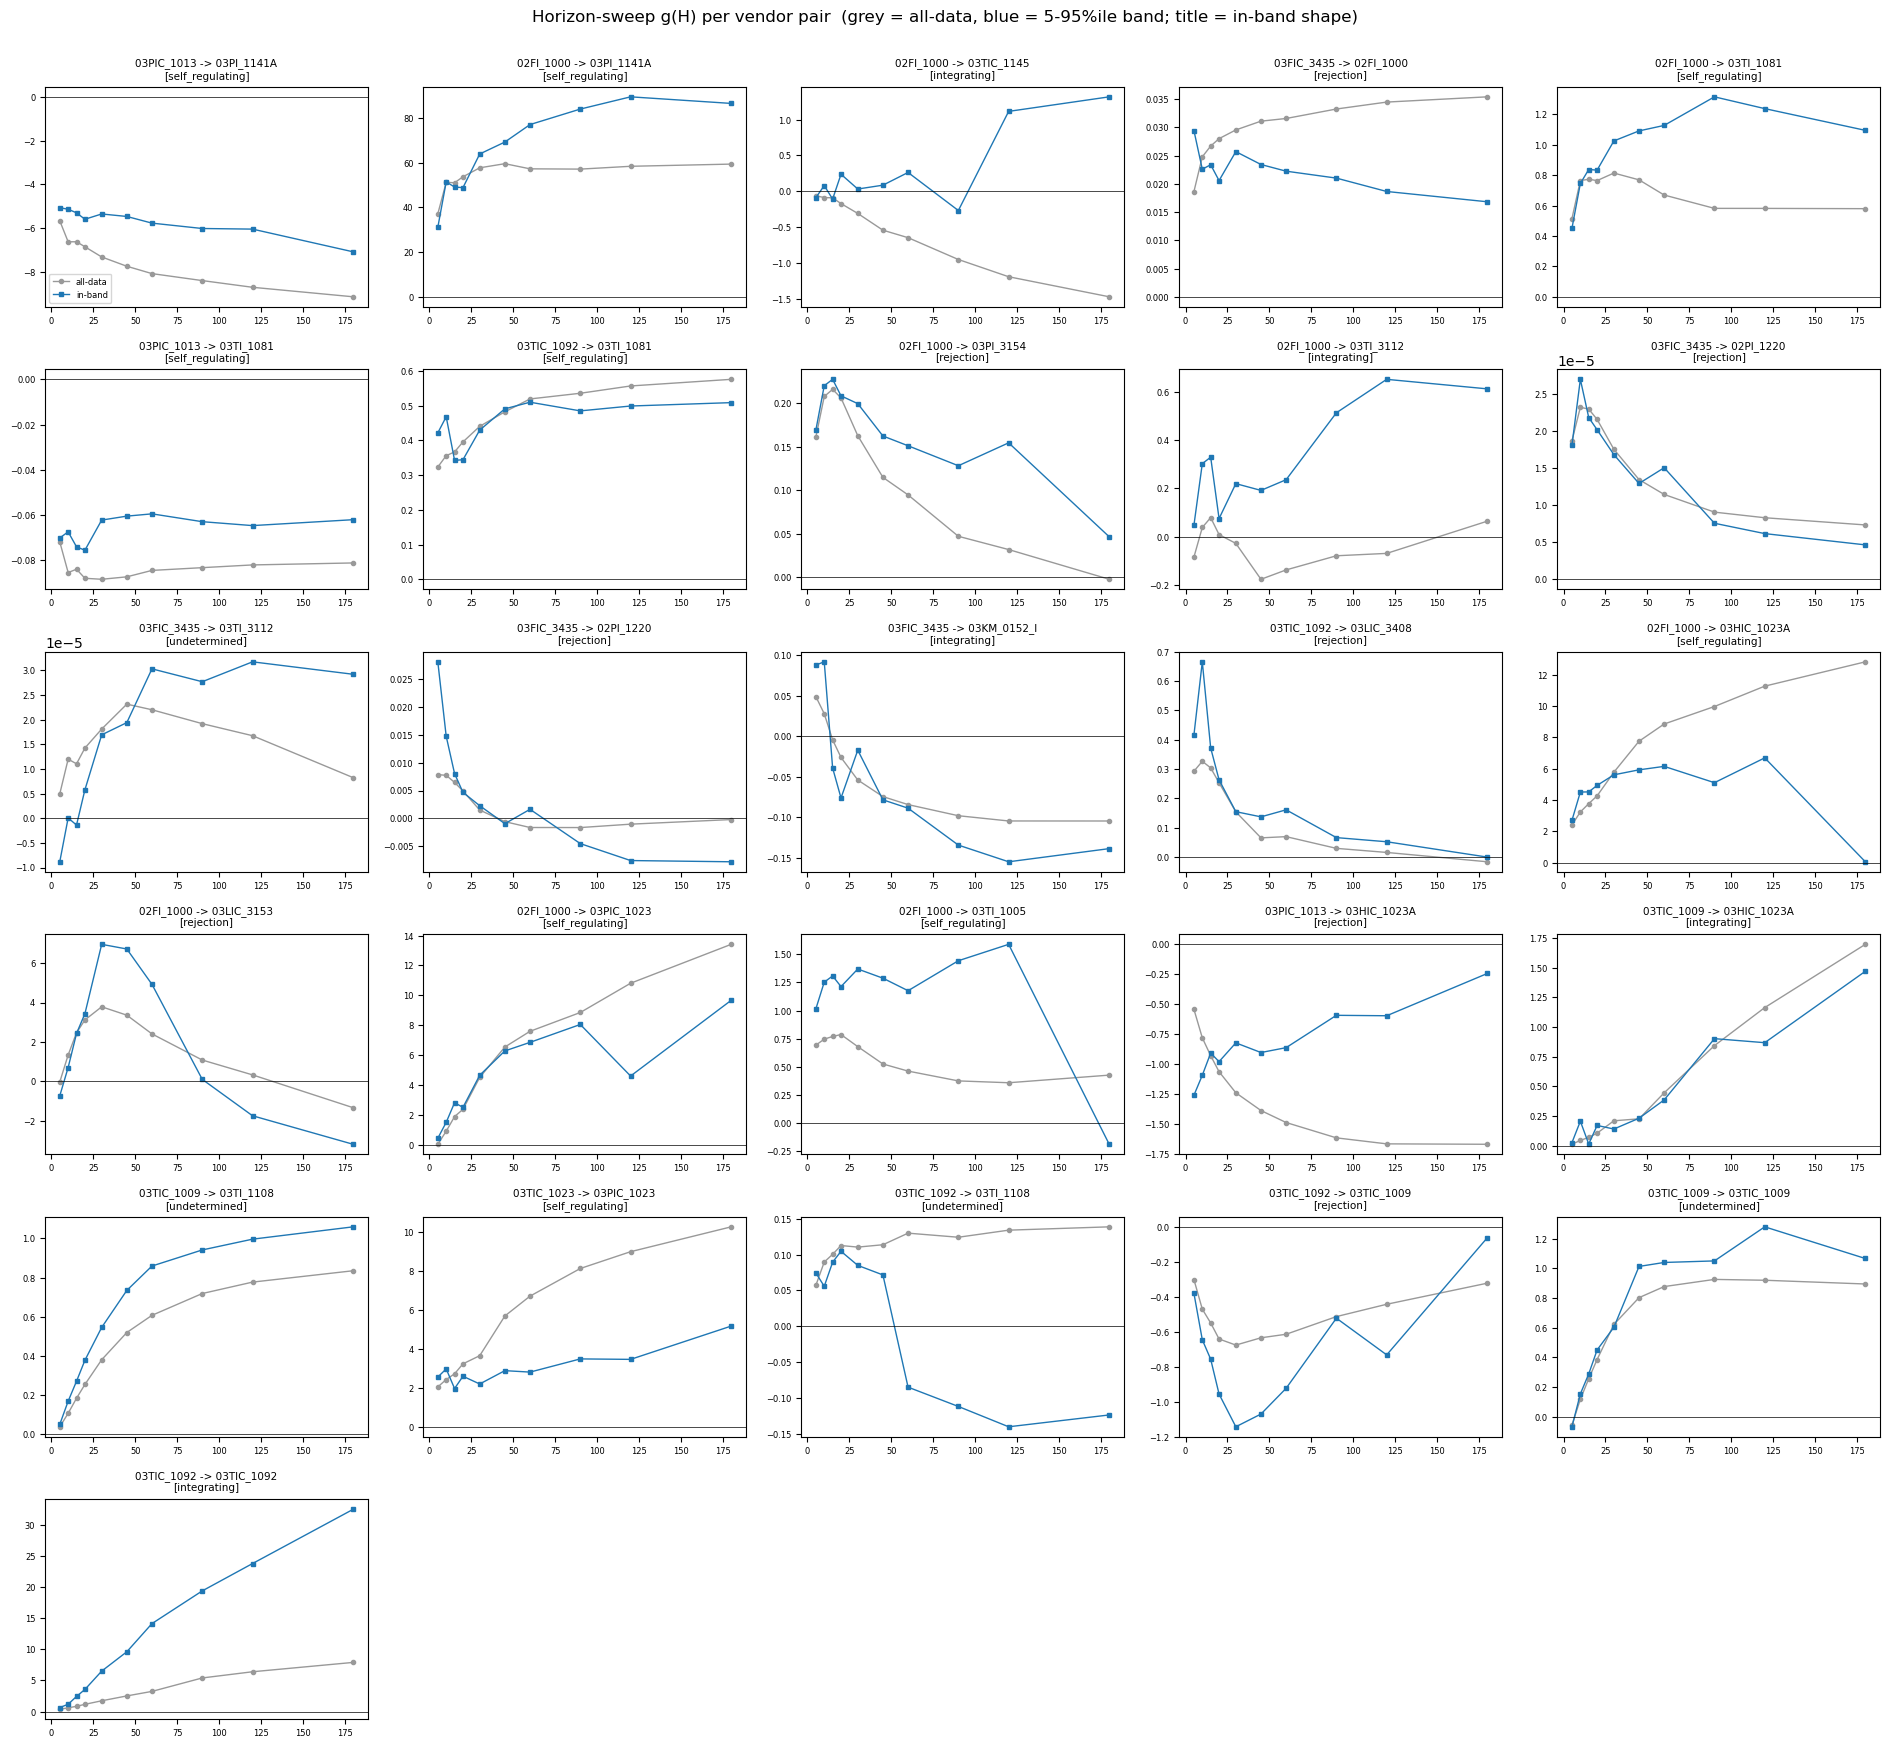


added sheet horizon_shapes -> /home/h604827/ControlActions/RESULTS/gain_response_framework/vendor_validation_1min.xlsx


In [4]:
# ============================================================================
#  HORIZON-SWEEP SHAPE for EVERY vendor pair  (all-data vs 5-95%ile band)
# ============================================================================
# Reuses the vendor frame `tsv`, `_vdiff`, `_vinputs_col` (column-matched de-confounders),
# `seg_band_v` from the cells above. For each pair we sweep g(H) and classify the shape the
# same way the framework does.
import matplotlib.pyplot as plt
HSW = np.array([5, 10, 15, 20, 30, 45, 60, 90, 120, 180], float)

def _vgpoint(cv, inp, mv, seg, H):
    """point (no-bootstrap) de-confounded gain of mv on cv at horizon H, on the vendor frame."""
    D = _vdiff(tsv, cv, inp, H, seg)
    ii = [c for c in inp if c == mv or (len(D) and D[c].std() > 0)]
    if len(D) < 50 or mv not in ii or D[mv].std() == 0:
        return np.nan
    y = D[cv].to_numpy(); X = np.column_stack([D[c].to_numpy() for c in ii] + [np.ones(len(D))])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(coef[ii.index(mv)])

def _fit_fo(Hgrid, g):
    ok = np.isfinite(g); H, gg = Hgrid[ok], g[ok]
    if len(H) < 4:
        return None
    best = None
    for tau in np.arange(2, 241, 2):
        for th in (0, 1, 2, 3, 5, 7.5, 10, 15):
            basis = 1 - np.exp(-np.clip(H - th, 0, None) / tau); den = float(basis @ basis)
            if den <= 1e-9:
                continue
            K = float(basis @ gg) / den; sse = float(((gg - K * basis) ** 2).sum())
            if best is None or sse < best['sse']:
                best = dict(K=K, tau=float(tau), theta=float(th), sse=sse)
    ss = float(((gg - gg.mean()) ** 2).sum()); best['r2'] = (1 - best['sse'] / ss) if ss > 0 else np.nan
    return best

def _shape(g, Hgrid):
    """same rules as the framework classifier: plateau / ramp / rise-then-decay / undetermined."""
    g = np.asarray(g, float)
    if np.all(~np.isfinite(g)) or np.nanmax(np.abs(g)) == 0:
        return dict(cls='undetermined', K=np.nan, tau=np.nan, theta=np.nan, fit_r2=np.nan, ramp=np.nan)
    i30 = int(np.argmin(np.abs(Hgrid - 30))); i120 = int(np.argmin(np.abs(Hgrid - 120)))
    g30, g120 = g[i30], g[i120]
    ramp = g120 / g30 if (np.isfinite(g30) and g30 != 0) else np.nan
    peak = int(np.nanargmax(np.abs(g)))
    decayed = (np.abs(g[-1]) < 0.6 * np.abs(g[peak])) and (peak < len(g) - 2)
    fo = _fit_fo(Hgrid, g)
    if decayed and not (np.isfinite(ramp) and ramp > 1.5):
        cls = 'rejection'
    elif np.isfinite(ramp) and ramp >= 2.5:
        cls = 'integrating'
    elif fo is not None and fo['r2'] >= 0.5 and np.isfinite(ramp) and abs(ramp - 1) < 0.8:
        cls = 'self_regulating'
    elif np.isfinite(ramp) and abs(ramp - 1) < 0.6:
        cls = 'self_regulating'
    else:
        cls = 'undetermined'
    return dict(cls=cls, K=(fo['K'] if fo else np.nan), tau=(fo['tau'] if fo else np.nan),
                theta=(fo['theta'] if fo else np.nan), fit_r2=(fo['r2'] if fo else np.nan), ramp=ramp)

# ---- sweep every pair on all-data and in-band (column-matched de-confounders) ----
shp_rows, sweeps_all, sweeps_band = [], {}, {}
for vmv, vcv, omv, ocv, vgn, cat, proxy in VPAIRS:
    key = f'{omv}->{ocv}'
    if omv not in _havev or ocv not in _havev:
        shp_rows.append(dict(category=cat, vendor_MV=vmv, vendor_CV=vcv, our_MV=omv, our_CV=ocv,
                             mv_proxy=proxy, vendor_gain=round(vgn, 3), shape_all='missing', shape_band='missing'))
        continue
    inp = _vinputs_col(omv, ocv, vcv)
    g_all  = np.array([_vgpoint(ocv, inp, omv, None,       H) for H in HSW])
    g_band = np.array([_vgpoint(ocv, inp, omv, seg_band_v, H) for H in HSW])
    sweeps_all[key], sweeps_band[key] = g_all, g_band
    sa, sb = _shape(g_all, HSW), _shape(g_band, HSW)
    g60a = g_all[HSW == 60][0]; g60b = g_band[HSW == 60][0]
    shp_rows.append(dict(
        category=cat, vendor_MV=vmv, vendor_CV=vcv, our_MV=omv, our_CV=ocv, mv_proxy=proxy,
        vendor_gain=round(vgn, 3), shape_all=sa['cls'], shape_band=sb['cls'],
        g60_all=round(g60a, 3) if np.isfinite(g60a) else np.nan,
        g60_band=round(g60b, 3) if np.isfinite(g60b) else np.nan,
        ramp_all=round(sa['ramp'], 2) if np.isfinite(sa['ramp']) else np.nan,
        ramp_band=round(sb['ramp'], 2) if np.isfinite(sb['ramp']) else np.nan,
        tau_band=round(sb['tau'], 0) if (sb['cls'] == 'self_regulating' and np.isfinite(sb['tau'])) else np.nan,
        theta_band=round(sb['theta'], 0) if (sb['cls'] == 'self_regulating' and np.isfinite(sb['theta'])) else np.nan,
        fitR2_band=round(sb['fit_r2'], 2) if np.isfinite(sb['fit_r2']) else np.nan))

shp = pd.DataFrame(shp_rows)
shp['_o'] = shp['category'].map(_cord)
shp = shp.sort_values(['_o', 'our_CV', 'our_MV']).drop(columns='_o').reset_index(drop=True)
pd.set_option('display.max_rows', 300); pd.set_option('display.width', 260)
print('====== HORIZON-SWEEP SHAPE per vendor pair (H = 5..180 min; all-data vs 5-95%ile band) ======\n')
print(shp[['category', 'our_MV', 'our_CV', 'vendor_gain', 'shape_all', 'shape_band',
           'g60_all', 'g60_band', 'tau_band', 'theta_band', 'fitR2_band']].to_string(index=False))
print('\nshape counts (in-band):');  print(shp['shape_band'].value_counts().to_string())
print('\nshape counts (all-data):'); print(shp['shape_all'].value_counts().to_string())

# ---- grid of all sweeps: grey = all-data, blue = in-band ----
keys = [f'{p[2]}->{p[3]}' for p in VPAIRS if f'{p[2]}->{p[3]}' in sweeps_all]
kmap = {f'{p[2]}->{p[3]}': p for p in VPAIRS}
ncol = 5; nrow = int(np.ceil(len(keys) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(19, 2.9 * nrow)); axes = np.atleast_1d(axes).ravel()
for ax, key in zip(axes, keys):
    p = kmap[key]; sb = _shape(sweeps_band[key], HSW)
    ax.plot(HSW, sweeps_all[key],  'o-', color='0.6', ms=3, lw=1, label='all-data')
    ax.plot(HSW, sweeps_band[key], 's-', color='C0',  ms=3, lw=1, label='in-band')
    ax.axhline(0, color='k', lw=.5)
    ax.set_title(f"{p[2][:-3]} -> {p[3][:-3]}\n[{sb['cls']}]", fontsize=7.5)
    ax.tick_params(labelsize=6)
for ax in axes[len(keys):]:
    ax.axis('off')
axes[0].legend(fontsize=6, loc='best')
fig.suptitle('Horizon-sweep g(H) per vendor pair  (grey = all-data, blue = 5-95%ile band; title = in-band shape)',
             fontsize=12, y=1.002)
plt.tight_layout(); plt.show()

# ---- add the shape table to the vendor validation workbook ----
with pd.ExcelWriter(f'{OUTV}/vendor_validation_1min.xlsx', engine='openpyxl', mode='a',
                    if_sheet_exists='replace') as xl:
    shp.to_excel(xl, sheet_name='horizon_shapes', index=False)
print(f'\nadded sheet horizon_shapes -> {OUTV}/vendor_validation_1min.xlsx')


## 7 - Derive the target: effect + timing map for `03LIC_1071`
With the estimator validated against the vendor matrix above, apply it to the target. Every handle (+ the feed disturbance) is scored, **restricted to the operating `REGIME`** — default `within_band` = the customer-supplied **5-95%ile steady operating band** (set `CONFIG['REGIME']='all'` for the full record). This is the regime that recovers the vendor gain magnitude (validated in Part 6 above).

**Hybrid mode-aware routing** for an integrating target:
- the **self valve** is read on **open-loop (MANUAL)** data intersected with the regime, via the rate method (reverse causation; reported as a 60-min-equivalent = rate x 60);
- **exogenous handles** use the **60-min level-difference**, keeping only windows whose *both* ends fall inside one regime segment.

The self valve is excluded from the de-confounder set for the other handles. (Feed-range stratification around the ~8.15-8.4 sweet spot is a further refinement, pending the true steady-state operating durations.)


In [11]:
handles = op_tags + [f'{t}.{d}__ev' for t, d in CONFIG['RECON'] if f'{t}.{d}__ev' in ts.columns]
FEED = '02FI_1000.PV'; SUP = '03LIC_1016.OP'
INPUTS = [h for h in handles if h in ts.columns and h != SELF_OP] + ([FEED] if FEED in ts.columns else [])

# ---- regime segments on the 30-sec grid: MANUAL (open-loop guard) + 5-95%ile steady band ----
def spans_to_seg(starts, ends):
    # give every grid row the index of the [start, end] window it falls inside (else NaN)
    a = np.asarray(starts, 'datetime64[ns]'); b = np.asarray(ends, 'datetime64[ns]')
    o = np.argsort(a); a, b = a[o], b[o]
    ii = ts.index.values.astype('datetime64[ns]')
    k = np.searchsorted(a, ii, side='right') - 1
    inside = (k >= 0) & (ii <= b[np.clip(k, 0, len(b) - 1)]) & ts[TARGET].notna().to_numpy()
    return pd.Series(np.where(inside, k, np.nan), index=ts.index)

_ms = manual_spans(TARGET)
seg_manual = spans_to_seg([b for b, e in _ms], [e for b, e in _ms]) if _ms else pd.Series(np.nan, index=ts.index)
man_mask = seg_manual.notna()

wl = pd.read_csv(CONFIG['WITHIN_BAND_CSV'])
wl['StartTime'] = pd.to_datetime(wl['StartTime'], errors='coerce')
wl['EndTime'] = pd.to_datetime(wl['EndTime'], errors='coerce')
wl = wl.dropna(subset=['StartTime', 'EndTime'])
seg_band = spans_to_seg(wl['StartTime'].values, wl['EndTime'].values)
band_mask = seg_band.notna()

REGIME = CONFIG.get('REGIME', 'within_band')
SEG = seg_band if REGIME == 'within_band' else None        # exogenous handles: 60-min windows must sit in one band period
self_mask = (man_mask & band_mask) if REGIME == 'within_band' else man_mask

TARGET_CLASS = classify_target(INPUTS)
analysis = handles + ([FEED] if FEED in ts.columns else [])
print(f'TARGET class {TARGET_CLASS} | REGIME {REGIME} | band {int(band_mask.sum()):,} rows '
      f'({100*band_mask.mean():.0f}% of grid) | self-valve open-loop+band {int(self_mask.sum()):,} rows')

def mk_row(h, role, regime, dyn, jg, r2s, theta, tim):
    base = dict(handle=h.replace('__ev', '(recon)'), role=role, regime=regime, dynamics=dyn,
                dead_min=round(theta, 1) if np.isfinite(theta) else np.nan,
                wait_min=tim['wait_min'], settle_min=tim['settle_min'], next_action_min=tim['next_action_min'])
    if jg is None:
        return {**base, 'gain_h60': np.nan, 'ci90': 'n/a', 'R2_solo': np.nan, 'confidence': 'undetermined'}
    return {**base, 'gain_h60': round(jg['g'], 3), 'ci90': f"[{jg['lo']:+.2f},{jg['hi']:+.2f}]",
            'R2_solo': round(r2s, 3) if np.isfinite(r2s) else np.nan,
            'confidence': confidence(jg['g'], jg['lo'], jg['hi'], r2s, jg['n'])}

rows = []
for h in analysis:
    theta = onset_xcorr(h)[0]
    if TARGET_CLASS == 'integrating' and h == SELF_OP:
        # self/controlled valve: OPEN-LOOP (manual) + regime, integrating RATE gain, as a 60-min level change (rate x 60)
        dec = [c for c in [FEED, SUP] if c in ts.columns]
        used_mask, reg_lbl = self_mask, f'open-loop+{REGIME}'
        rg = rate_gain1(h, used_mask, dec, thin=4)
        if rg is None:                                      # in-band manual too sparse -> fall back to all manual
            used_mask, reg_lbl = man_mask, 'open-loop(MANUAL)'
            rg = rate_gain1(h, used_mask, dec, thin=4)
        jg = None if rg is None else dict(g=rg['g'] * 60, lo=rg['lo'] * 60, hi=rg['hi'] * 60, n=rg['n'])
        rows.append(mk_row(h, 'self valve', reg_lbl, 'integrating', jg,
                           rate_solo_r2(h, used_mask)[0], theta, action_timing(theta, np.nan, 'integrating')))
        continue
    # exogenous handle / feed: de-confounded 60-min level-difference gain, restricted to the regime segments
    cl = classify(horizon_sweep(TARGET, INPUTS, h, SEG))
    ci = gain_ci(TARGET, INPUTS, h, 60, SEG); r2s = solo_r2(TARGET, h, 60, SEG)
    role = 'feed(disturbance)' if h == FEED else 'handle'
    rows.append(mk_row(h, role, REGIME, cl['cls'], ci if np.isfinite(ci['g']) else None,
                       r2s, theta, action_timing(theta, cl['tau'], cl['cls'])))
order = {'high': 0, 'medium': 1, 'directional': 2, 'undetermined': 3}
eff = pd.DataFrame(rows)
eff['_o'] = eff['confidence'].map(order)
eff = eff.sort_values(['_o', 'R2_solo'], ascending=[True, False], na_position='last').drop(columns='_o')
print(f'\nEFFECT + TIMING MAP: handles -> {TARGET}  [regime={REGIME}]  (gain_h60 = level %-change per unit over 60 min)\n')
print(eff.to_string(index=False))

OUT = '/home/h604827/ControlActions/RESULTS/gain_response_framework'
os.makedirs(OUT, exist_ok=True)
eff.to_excel(f'{OUT}/{TARGET.split(".")[0]}_effect_timing_map_{REGIME}.xlsx', index=False)
print('\nsaved ->', f'{OUT}/{TARGET.split(".")[0]}_effect_timing_map_{REGIME}.xlsx')

TARGET class integrating | REGIME within_band | band 616,773 rows (13% of grid) | self-valve open-loop+band 172 rows

EFFECT + TIMING MAP: handles -> 03LIC_1071.PV  [regime=within_band]  (gain_h60 = level %-change per unit over 60 min)

              handle              role            regime     dynamics  dead_min  wait_min  settle_min  next_action_min  gain_h60          ci90  R2_solo   confidence
       03LIC_1016.OP            handle       within_band    rejection       5.5       5.5         NaN              NaN    -0.307 [-0.39,-0.25]    0.094       medium
        02FI_1000.PV feed(disturbance)       within_band    rejection       0.5       0.5         NaN              NaN    -2.787 [-3.85,-1.91]    0.032       medium
       03LIC_1071.OP        self valve open-loop(MANUAL)  integrating       0.0       0.0         NaN              5.0     5.123 [+2.76,+7.56]    0.016  directional
       03LIC_3178.OP            handle       within_band    rejection       0.5       0.5         NaN  

## 8 - Applying the framework to another alarm tag

1. Set `CONFIG['TARGET']` to the new alarm tag (`.PV`), and add any handles that must be reconstructed from events to `CONFIG['RECON']`.
2. Re-run. The framework will: auto-discover `.OP` handles, find the self valve by instrument number, auto-classify the target (integrating vs self-regulating), route the self valve to open-loop, and produce the effect+timing map with honest confidence.
3. Validate on any vendor pairs available for that area (Part 6 pattern).

**Reading the output** — `gain_h60`: level %-change per unit handle over 60 min (self valve = rate x 60); `dead_min`: wait at least this long before expecting a response; `settle_min`/`next_action_min`: when the effect is ~complete / when to re-evaluate; `confidence`: `high`/`medium` (sign + magnitude), `directional` (sign only), `undetermined` (not identifiable).

**Honest limits**: closed-loop control masks effects on all-data (handles tagged `rejection` in the sweep); MANUAL data is sparse so the self-valve magnitude is `directional`; the level is integrating so it has no steady-state gain (rate-based). Extend later: open-loop evaluation for cascade-coupled handles, SP handles (mode-aware), operating-point stratification.